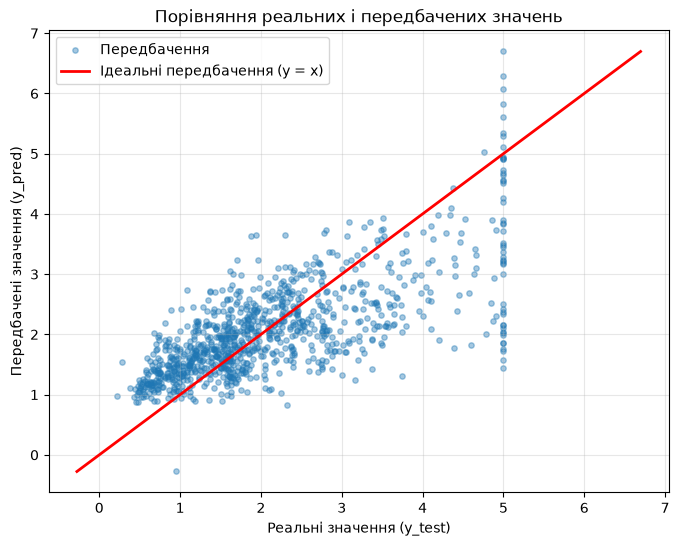

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# завантажуємо датасет
data = fetch_california_housing(as_frame=True)
df = data.frame

# беремо випадкові 5000 рядків
df_sample = df.sample(n=5000, random_state=42)

# ознаки та ціль
X = df_sample[['MedInc', 'AveRooms']]
y = df_sample['MedHouseVal']

# розділяємо на навчальну і тестову вибірки 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# навчаємо модель
model = LinearRegression()
model.fit(X_train, y_train)

# передбачення
y_pred = model.predict(X_test)

# побудова графіка
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, s=15, label='Передбачення')

# лінія ідеальних передбачень y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Ідеальні передбачення (y = x)')

plt.xlabel('Реальні значення (y_test)')
plt.ylabel('Передбачені значення (y_pred)')
plt.title('Порівняння реальних і передбачених значень')
plt.legend()
plt.grid(True, alpha=0.3)

# збереження графіка у файл
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()